In [1]:
from langgraph.graph import StateGraph, START, END


In [13]:
from typing import TypedDict,Literal

In [3]:
class QuadState(TypedDict):
    a:int
    b:int
    c:int
    equation:str
    discriminant:float
    result:str

In [ ]:
def show_equation(QuadState):
    a = QuadState['a']
    b = QuadState['b']
    c = QuadState['c']
    equation = f"{a}x^2 + {b}x + {c} = 0"
    return {'equation':equation}   

In [6]:
def calculate_discriminant(QuadState):
    a = QuadState['a']
    b = QuadState['b']
    c = QuadState['c']
    discriminant = b**2 - 4*a*c
    return {'discriminant':discriminant}

In [15]:
def real_roots(state:QuadState):
    a = state['a']
    b = state['b']
    c = state['c']
    d = state['discriminant']
    
    root1 = (-b + d**0.5) / (2*a)
    root2 = (-b - d**0.5) / (2*a)
    
    return {'result':f"Two distinct real roots: {root1} and {root2}"}

In [16]:
def repeated_roots(state:QuadState):
    a = state['a']
    b = state['b']
    
    root = -b / (2*a)
    
    return {'result':f"One repeated real root: {root}"}

In [17]:
def complex_roots(state:QuadState):
    result = f"No real roots"
    return {'result':result}

In [18]:
def check_condition(state:QuadState) -> Literal["real_roots","repeated_roots","complex_roots"]:
    d = state['discriminant']
    if d > 0:
        return "real_roots"
    elif d==0:
        return "repeated_roots"
    else:
        return "complex_roots"

In [23]:
graph = StateGraph(QuadState)
graph.add_node('show_equation',show_equation)
graph.add_node('calculate_discriminant',calculate_discriminant)
graph.add_node('real_roots',real_roots)
graph.add_node('repeated_roots',repeated_roots)
graph.add_node('complex_roots',complex_roots)

graph.add_edge(START,'show_equation')
graph.add_edge('show_equation','calculate_discriminant')
graph.add_conditional_edges('calculate_discriminant',check_condition)
graph.add_edge("real_roots",END)
graph.add_edge("repeated_roots",END)
graph.add_edge("complex_roots",END)

workflow = graph.compile()

In [28]:

initial_state ={
    'a':2,
    'b':4,
    'c':2
}

workflow.invoke(initial_state)


{'a': 2,
 'b': 4,
 'c': 2,
 'equation': '2x^2 + 4x + 2 = 0',
 'discriminant': 0,
 'result': 'One repeated real root: -1.0'}

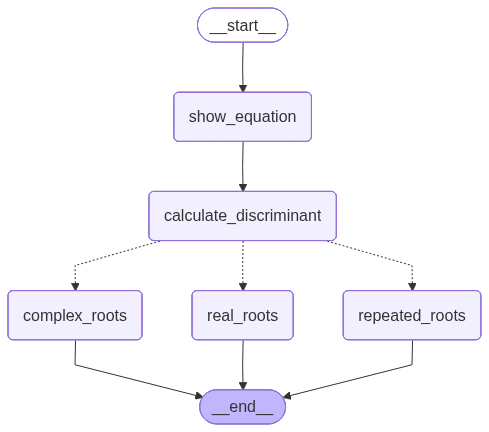

In [24]:
from IPython.display import Image

Image(workflow.get_graph().draw_mermaid_png())